<a href="https://colab.research.google.com/github/tapasya98/EDA_Capstone_Project/blob/main/IPL(_Python%2BSQL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=3da1ebc46af5063f494f9cb1ccef6bb08b8493fa3f3699012b9872aa0d890ec4
  Stored in directory: /root/.cache/pip/wheels/68/5d/a5/edc271b998f909801d7956959f699b976cc9896075dc47c153
Successfully built pandasql


In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt  #for visualization
import matplotlib.cm as cm
import seaborn as sns             #for visualization
import plotly.express as px
import warnings                   #to ignore warnings
warnings.filterwarnings('ignore')

In [ ]:
IPL_df = pd.read_csv('/content/drive/MyDrive/Dataset_Tech/IPL_Matches.csv',encoding='unicode_escape')

In [ ]:
IPL_df.head().T

,0,1,2,3,4
id,335982,335983,335984,335985,335986
city,Bangalore,Chandigarh,Delhi,Mumbai,Kolkata
date,2008-04-18,2008-04-19,2008-04-19,2008-04-20,2008-04-20
player_of_match,BB McCullum,MEK Hussey,MF Maharoof,MV Boucher,DJ Hussey
venue,M Chinnaswamy Stadium,"Punjab Cricket Association Stadium, Mohali",Feroz Shah Kotla,Wankhede Stadium,Eden Gardens
neutral_venue,0,0,0,0,0
team1,Royal Challengers Bangalore,Kings XI Punjab,Delhi Daredevils,Mumbai Indians,Kolkata Knight Riders
team2,Kolkata Knight Riders,Chennai Super Kings,Rajasthan Royals,Royal Challengers Bangalore,Deccan Chargers
toss_winner,Royal Challengers Bangalore,Chennai Super Kings,Rajasthan Royals,Mumbai Indians,Deccan Chargers
toss_decision,field,bat,bat,bat,bat


In [ ]:
IPL_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    int64  
 1   city             803 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  812 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    int64  
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           812 non-null    object 
 11  result           812 non-null    object 
 12  result_margin    799 non-null    float64
 13  eliminator       812 non-null    object 
 14  method           19 non-null     object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    object 
dtypes: float64(1), i

In [ ]:
# change datatype of date
IPL_df['date'] = pd.to_datetime(IPL_df['date'], dayfirst=True)

# extract year from date
IPL_df['year'] = IPL_df['date'].dt.year


In [ ]:
# print column and rows
IPL_df.shape

(816, 18)

In [ ]:
# check duplicte values
IPL_df.duplicated().sum()

np.int64(0)

In [ ]:
# check null values
IPL_df.isnull().sum()

,0
id,0
city,13
date,0
player_of_match,4
venue,0
neutral_venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0


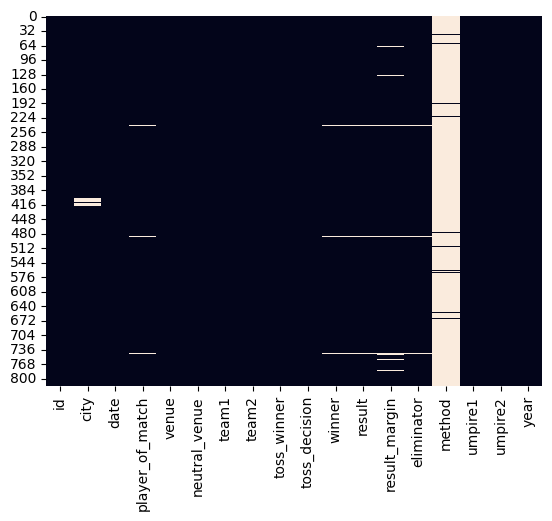

In [ ]:
# Visualizing the missing values
# Checking Null Value by plotting Heatmap
sns.heatmap(IPL_df.isnull(), cbar=False)
plt.size = (12,6)
plt.show()

## SQL Query

In [ ]:
conn = sqlite3.connect('IPL.db')
IPL_df.to_sql('IPL',conn,if_exists='replace', index=False)
conn.close()

In [ ]:
conn = sqlite3.connect('IPL.db')
conn.commit()
IPL_df = pd.read_sql_query('SELECT * FROM IPL', conn)

In [ ]:
pd.read_sql_query ('''
select * from IPL
limit 5
''',conn)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,year
0,335982,Bangalore,2008-04-18 00:00:00,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,None,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,2008-04-19 00:00:00,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,None,MR Benson,SL Shastri,2008
2,335984,Delhi,2008-04-19 00:00:00,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,None,Aleem Dar,GA Pratapkumar,2008
3,335985,Mumbai,2008-04-20 00:00:00,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,None,SJ Davis,DJ Harper,2008
4,335986,Kolkata,2008-04-20 00:00:00,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,None,BF Bowden,K Hariharan,2008


In [ ]:
IPL_df['date'] = pd.to_datetime(IPL_df['date'])
IPL_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               816 non-null    int64         
 1   city             803 non-null    object        
 2   date             816 non-null    datetime64[ns]
 3   player_of_match  812 non-null    object        
 4   venue            816 non-null    object        
 5   neutral_venue    816 non-null    int64         
 6   team1            816 non-null    object        
 7   team2            816 non-null    object        
 8   toss_winner      816 non-null    object        
 9   toss_decision    816 non-null    object        
 10  winner           812 non-null    object        
 11  result           812 non-null    object        
 12  result_margin    799 non-null    float64       
 13  eliminator       812 non-null    object        
 14  method           19 non-null     object   

### Fill Null Values

In [ ]:
# To Know about the null values

q_nulls = pd.read_sql_query('''
SELECT
  SUM(CASE WHEN id IS NULL THEN 1 ELSE 0 END) AS id_nulls,
  SUM(CASE WHEN city IS NULL THEN 1 ELSE 0 END) AS city_nulls,
  SUM(CASE WHEN date IS NULL THEN 1 ELSE 0 END) AS date_nulls,
  SUM(CASE WHEN player_of_match IS NULL THEN 1 ELSE 0 END) AS pom_nulls,
  SUM(CASE WHEN venue IS NULL THEN 1 ELSE 0 END) AS venue_nulls,
  SUM(CASE WHEN team1 IS NULL THEN 1 ELSE 0 END) AS team1_nulls,
  SUM(CASE WHEN team2 IS NULL THEN 1 ELSE 0 END) AS team2_nulls,
  SUM(CASE WHEN toss_winner IS NULL THEN 1 ELSE 0 END) AS toss_winner_nulls,
  SUM(CASE WHEN toss_decision IS NULL THEN 1 ELSE 0 END) AS toss_decision_nulls,
  SUM(CASE WHEN winner IS NULL THEN 1 ELSE 0 END) AS winner_nulls,
  SUM(CASE WHEN result IS NULL THEN 1 ELSE 0 END) AS result_nulls,
  SUM(CASE WHEN result_margin IS NULL THEN 1 ELSE 0 END) AS margin_nulls,
  SUM(CASE WHEN eliminator IS NULL THEN 1 ELSE 0 END) AS eliminator_nulls,
  SUM(CASE WHEN method IS NULL THEN 1 ELSE 0 END) AS method_nulls,
  SUM(CASE WHEN umpire1 IS NULL THEN 1 ELSE 0 END) AS umpire1_nulls,
  SUM(CASE WHEN umpire2 IS NULL THEN 1 ELSE 0 END) AS umpire2_nulls
FROM IPL -- Changed 'df' to 'IPL' to match the table name in the database
''', conn)

q_nulls

,id_nulls,city_nulls,date_nulls,pom_nulls,venue_nulls,team1_nulls,team2_nulls,toss_winner_nulls,toss_decision_nulls,winner_nulls,result_nulls,margin_nulls,eliminator_nulls,method_nulls,umpire1_nulls,umpire2_nulls
0,0,13,0,4,0,0,0,0,0,4,4,17,4,797,0,0


#### Null values Of City


In [ ]:
# check null values of city
pd.read_sql_query ('''
select * from IPL
where city is null
''',conn)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,year
0,729281,None,2014-04-17 00:00:00,YS Chahal,Sharjah Cricket Stadium,1,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,8.0,N,None,Aleem Dar,S Ravi,2014
1,729287,None,2014-04-19 00:00:00,PA Patel,Dubai International Cricket Stadium,1,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,N,None,Aleem Dar,AK Chaudhary,2014
2,729289,None,2014-04-19 00:00:00,JP Duminy,Dubai International Cricket Stadium,1,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,Delhi Daredevils,wickets,4.0,N,None,Aleem Dar,VA Kulkarni,2014
3,729291,None,2014-04-20 00:00:00,GJ Maxwell,Sharjah Cricket Stadium,1,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,7.0,N,None,BF Bowden,M Erasmus,2014
4,729295,None,2014-04-22 00:00:00,GJ Maxwell,Sharjah Cricket Stadium,1,Kings XI Punjab,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kings XI Punjab,runs,72.0,N,None,M Erasmus,S Ravi,2014
5,729297,None,2014-04-23 00:00:00,RA Jadeja,Dubai International Cricket Stadium,1,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,field,Chennai Super Kings,runs,7.0,N,None,HDPK Dharmasena,RK Illingworth,2014
6,729299,None,2014-04-24 00:00:00,CA Lynn,Sharjah Cricket Stadium,1,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,2.0,N,None,Aleem Dar,VA Kulkarni,2014
7,729301,None,2014-04-25 00:00:00,AJ Finch,Dubai International Cricket Stadium,1,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,4.0,N,None,M Erasmus,S Ravi,2014
8,729303,None,2014-04-25 00:00:00,MM Sharma,Dubai International Cricket Stadium,1,Chennai Super Kings,Mumbai Indians,Mumbai Indians,bat,Chennai Super Kings,wickets,7.0,N,None,BF Bowden,M Erasmus,2014
9,729309,None,2014-04-27 00:00:00,M Vijay,Sharjah Cricket Stadium,1,Delhi Daredevils,Mumbai Indians,Mumbai Indians,bat,Delhi Daredevils,wickets,6.0,N,None,Aleem Dar,VA Kulkarni,2014


In [ ]:
# Fill Null values of 'CITY'
conn.execute('''
UPDATE IPL SET city =
  CASE
    WHEN venue = 'Sharjah Cricket Stadium' THEN 'Sharjah'
    WHEN venue = 'Dubai International Cricket Stadium' THEN 'Dubai'
    ELSE city
  END
WHERE city IS NULL
''')
conn.commit()


# Check update
pd.read_sql_query('''
SELECT COUNT(*) AS null_city_count
FROM IPL
WHERE city IS NULL
''', conn)

,null_city_count
0,0


####  Null values of Player of the match

In [ ]:
# Check null values of player of the match
pd.read_sql_query ('''
select * from IPL
where player_of_match is null
''',conn)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,year
0,501265,Delhi,2011-05-21 00:00:00,None,Feroz Shah Kotla,0,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,None,None,None,None,None,SS Hazare,RJ Tucker,2011
1,829763,Bangalore,2015-04-29 00:00:00,None,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,None,None,None,None,None,JD Cloete,PG Pathak,2015
2,829813,Bangalore,2015-05-17 00:00:00,None,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,None,None,None,None,None,HDPK Dharmasena,K Srinivasan,2015
3,1178424,Bengaluru,2019-04-30 00:00:00,None,M.Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,None,None,None,None,None,UV Gandhe,NJ Llong,2019


In [ ]:
# Fill null values of player of match
conn.execute('''
UPDATE IPL SET player_of_match = 'Match Cancelled'
WHERE player_of_match IS NULL
''')
conn.commit()


# Check update
pd.read_sql_query('''
SELECT COUNT(*) AS remaining_nulls_in_player_of_match
FROM IPL
WHERE player_of_match IS NULL
''', conn)

,remaining_nulls_in_player_of_match
0,0


####  Null values of Winner and Result

In [ ]:
# check null values of winner and result
pd.read_sql_query ('''
select * from IPL
where winner is null and result is null
''',conn)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,year
0,501265,Delhi,2011-05-21 00:00:00,Match Cancelled,Feroz Shah Kotla,0,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,None,None,None,None,None,SS Hazare,RJ Tucker,2011
1,829763,Bangalore,2015-04-29 00:00:00,Match Cancelled,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,None,None,None,None,None,JD Cloete,PG Pathak,2015
2,829813,Bangalore,2015-05-17 00:00:00,Match Cancelled,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,None,None,None,None,None,HDPK Dharmasena,K Srinivasan,2015
3,1178424,Bengaluru,2019-04-30 00:00:00,Match Cancelled,M.Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,None,None,None,None,None,UV Gandhe,NJ Llong,2019


In [ ]:
# fill null values of winner and result with match cancelled
conn.execute('''
UPDATE IPL SET winner = 'Match Cancelled', result = 'Match Cancelled'
WHERE winner IS NULL AND result IS NULL
''')
conn.commit()


# Check update
pd.read_sql_query('''
SELECT COUNT(*) AS remaining_nulls_in_pom_and_winner_and_result
FROM IPL
WHERE player_of_match IS NULL AND winner IS NULL AND result IS NULL
''', conn)

,remaining_nulls_in_pom_and_winner_and_result
0,0


####  Null values of Result Margin

In [ ]:
# check null values of result margin
pd.read_sql_query ('''
select * from IPL
where result_margin is null
''',conn)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,year
0,392190,Cape Town,2009-04-23 00:00:00,YK Pathan,Newlands,1,Kolkata Knight Riders,Rajasthan Royals,Kolkata Knight Riders,field,Rajasthan Royals,tie,None,Y,None,MR Benson,M Erasmus,2009
1,419121,Chennai,2010-03-21 00:00:00,J Theron,"MA Chidambaram Stadium, Chepauk",0,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,field,Kings XI Punjab,tie,None,Y,None,K Hariharan,DJ Harper,2010
2,501265,Delhi,2011-05-21 00:00:00,Match Cancelled,Feroz Shah Kotla,0,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,Match Cancelled,Match Cancelled,None,None,None,SS Hazare,RJ Tucker,2011
3,598004,Hyderabad,2013-04-07 00:00:00,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",0,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,Sunrisers Hyderabad,tie,None,Y,None,AK Chaudhary,S Ravi,2013
4,598017,Bangalore,2013-04-16 00:00:00,V Kohli,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Royal Challengers Bangalore,tie,None,Y,None,M Erasmus,VA Kulkarni,2013
5,729315,Abu Dhabi,2014-04-29 00:00:00,JP Faulkner,Sheikh Zayed Stadium,1,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,bat,Rajasthan Royals,tie,None,Y,None,Aleem Dar,AK Chaudhary,2014
6,829741,Ahmedabad,2015-04-21 00:00:00,SE Marsh,"Sardar Patel Stadium, Motera",0,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,tie,None,Y,None,M Erasmus,S Ravi,2015
7,829763,Bangalore,2015-04-29 00:00:00,Match Cancelled,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,Match Cancelled,Match Cancelled,None,None,None,JD Cloete,PG Pathak,2015
8,829813,Bangalore,2015-05-17 00:00:00,Match Cancelled,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Match Cancelled,Match Cancelled,None,None,None,HDPK Dharmasena,K Srinivasan,2015
9,1082625,Rajkot,2017-04-29 00:00:00,KH Pandya,Saurashtra Cricket Association Stadium,0,Gujarat Lions,Mumbai Indians,Gujarat Lions,bat,Mumbai Indians,tie,None,Y,None,AK Chaudhary,CB Gaffaney,2017


In [ ]:
# Replace null values of result margin with
conn.execute('''
UPDATE IPL SET result_margin = 0
WHERE result_margin IS NULL
''')
conn.commit()


# confirm updation
pd.read_sql_query('''
SELECT COUNT(*) AS remaining_nulls_in_result_margin
FROM IPL
WHERE result_margin IS NULL
''', conn)

,remaining_nulls_in_result_margin
0,0


#### Null values of Eliminator

In [ ]:
# check null values of eliminator
pd.read_sql_query ('''
select * from IPL
where eliminator is null
''',conn)


,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,year
0,501265,Delhi,2011-05-21 00:00:00,Match Cancelled,Feroz Shah Kotla,0,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,Match Cancelled,Match Cancelled,0.0,None,None,SS Hazare,RJ Tucker,2011
1,829763,Bangalore,2015-04-29 00:00:00,Match Cancelled,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,Match Cancelled,Match Cancelled,0.0,None,None,JD Cloete,PG Pathak,2015
2,829813,Bangalore,2015-05-17 00:00:00,Match Cancelled,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Match Cancelled,Match Cancelled,0.0,None,None,HDPK Dharmasena,K Srinivasan,2015
3,1178424,Bengaluru,2019-04-30 00:00:00,Match Cancelled,M.Chinnaswamy Stadium,0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,Match Cancelled,Match Cancelled,0.0,None,None,UV Gandhe,NJ Llong,2019


In [ ]:
# Replace null  values of eliminator with Match cancelled
conn.execute('''
UPDATE IPL SET eliminator = 'Match Cancelled'
WHERE eliminator IS NULL
''')
conn.commit()


# confirm updation
pd.read_sql_query('''
SELECT COUNT(*) AS remaining_nulls_in_eliminator
FROM IPL
WHERE eliminator IS NULL
''', conn)

,remaining_nulls_in_eliminator
0,0


#### NULL values of Method column

In [ ]:
# check null values of method column
pd.read_sql_query ('''
select * from IPL
where method is null
''',conn)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,year
0,335982,Bangalore,2008-04-18 00:00:00,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,None,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,2008-04-19 00:00:00,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,None,MR Benson,SL Shastri,2008
2,335984,Delhi,2008-04-19 00:00:00,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,None,Aleem Dar,GA Pratapkumar,2008
3,335985,Mumbai,2008-04-20 00:00:00,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,None,SJ Davis,DJ Harper,2008
4,335986,Kolkata,2008-04-20 00:00:00,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,None,BF Bowden,K Hariharan,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792,1216547,Dubai,2020-09-28 00:00:00,AB de Villiers,Dubai International Cricket Stadium,0,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,tie,0.0,Y,None,Nitin Menon,PR Reiffel,2020
793,1237177,Dubai,2020-11-05 00:00:00,JJ Bumrah,Dubai International Cricket Stadium,0,Mumbai Indians,Delhi Capitals,Delhi Capitals,field,Mumbai Indians,runs,57.0,N,None,CB Gaffaney,Nitin Menon,2020
794,1237178,Abu Dhabi,2020-11-06 00:00:00,KS Williamson,Sheikh Zayed Stadium,0,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,wickets,6.0,N,None,PR Reiffel,S Ravi,2020
795,1237180,Abu Dhabi,2020-11-08 00:00:00,MP Stoinis,Sheikh Zayed Stadium,0,Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,runs,17.0,N,None,PR Reiffel,S Ravi,2020


In [ ]:
# Replace null values and 0 values of method is with
conn.execute('''
UPDATE IPL SET method = 'No Result'
WHERE method IS NULL
''')
conn.commit()

# Check update
pd.read_sql_query('''
SELECT COUNT(*) AS remaining_nulls_in_method
FROM IPL
WHERE method IS NULL
''', conn)

,remaining_nulls_in_method
0,0


In [ ]:
# check updation of null values
IPL_df = pd.read_sql_query("SELECT * FROM IPL", conn)
IPL_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    int64  
 1   city             816 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  816 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    int64  
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           816 non-null    object 
 11  result           816 non-null    object 
 12  result_margin    816 non-null    float64
 13  eliminator       816 non-null    object 
 14  method           816 non-null    object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    object 
 17  year            

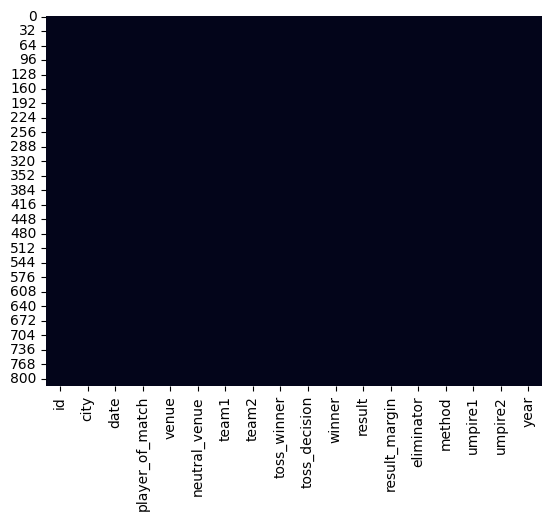

In [ ]:
# visualization of null values
sns.heatmap(IPL_df.isnull(), cbar=False)
plt.size = (12,6)
plt.show()

In [ ]:
conn = sqlite3.connect('IPL.db')
conn.commit()
IPL_df = pd.read_sql_query("SELECT * FROM IPL", conn)
IPL_df.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,year
0,335982,Bangalore,2008-04-18 00:00:00,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,No Result,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,2008-04-19 00:00:00,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,No Result,MR Benson,SL Shastri,2008
2,335984,Delhi,2008-04-19 00:00:00,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,No Result,Aleem Dar,GA Pratapkumar,2008
3,335985,Mumbai,2008-04-20 00:00:00,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,No Result,SJ Davis,DJ Harper,2008
4,335986,Kolkata,2008-04-20 00:00:00,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,No Result,BF Bowden,K Hariharan,2008


### Visualization

In [ ]:
# Total Matches played in each City
city_count = pd.read_sql_query ('''
select city,count(*) as matches_count from IPL
group by city
order by matches_count desc
''',conn)

city_count

,city,matches_count
0,Mumbai,101
1,Kolkata,77
2,Delhi,74
3,Bangalore,65
4,Hyderabad,64
5,Chennai,57
6,Chandigarh,56
7,Jaipur,47
8,Pune,38
9,Dubai,33


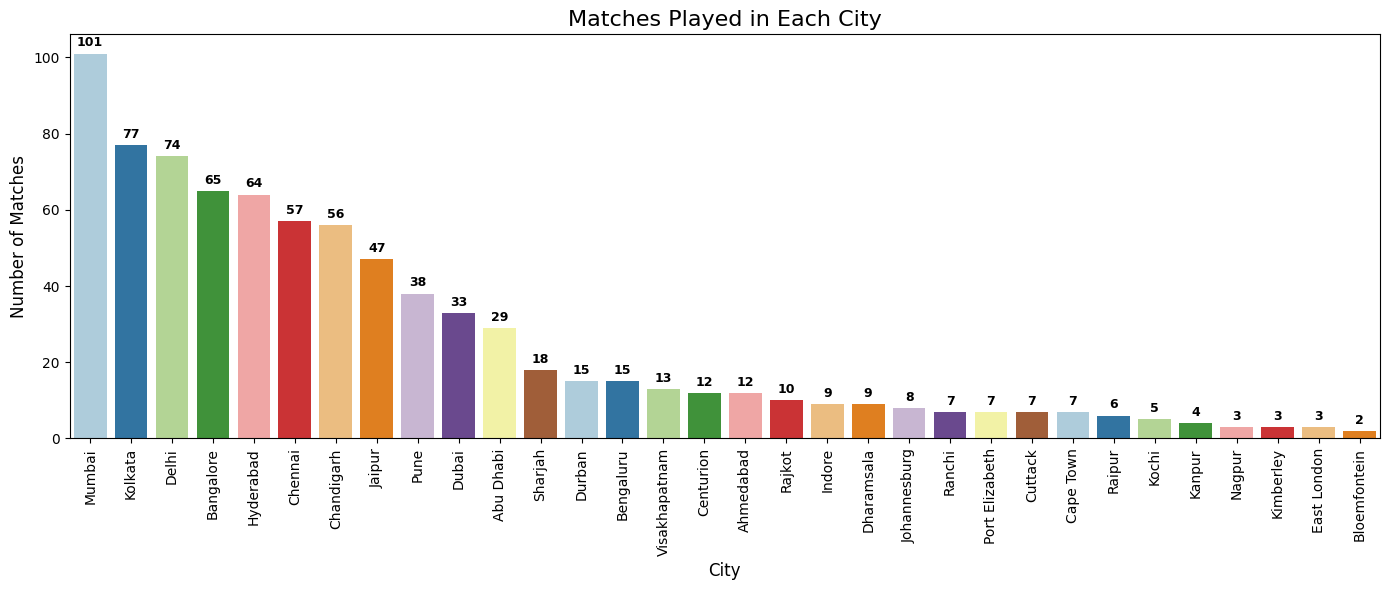

In [ ]:
# Create a bar chart for matches played in each city
plt.figure(figsize=(14,6))
ax = sns.barplot(x='city', y='matches_count', data=city_count, palette='Paired')
# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=9, fontweight='bold')

plt.title('Matches Played in Each City', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
#  Top 10 venue where most of IPL matches played
top_venue = pd.read_sql_query ('''
select venue,count(*) as count from IPL
group by venue
order by count desc
limit 10
''',conn)

top_venue

,venue,count
0,Eden Gardens,77
1,Feroz Shah Kotla,74
2,Wankhede Stadium,73
3,M Chinnaswamy Stadium,65
4,"Rajiv Gandhi International Stadium, Uppal",64
5,"MA Chidambaram Stadium, Chepauk",57
6,Sawai Mansingh Stadium,47
7,"Punjab Cricket Association Stadium, Mohali",35
8,Dubai International Cricket Stadium,33
9,Sheikh Zayed Stadium,29


In [ ]:
# visualization
fig = px.pie(top_venue,
             values='count',
             names='venue',
             title='Top 10 venue where most of IPL matches played',
             color_discrete_sequence=px.colors.qualitative.D3,
             width=800,
             height=600,
             )

fig.update_traces(textposition='inside', textinfo='percent', hole=0.4)

fig.show()



In [ ]:
# Total Matches per Season
season_count = pd.read_sql_query ('''
select year,count(*) as count from IPL
group by year
order by count desc
''',conn)

season_count

,year,count
0,2013,76
1,2012,74
2,2011,73
3,2020,60
4,2019,60
5,2018,60
6,2016,60
7,2014,60
8,2010,60
9,2017,59


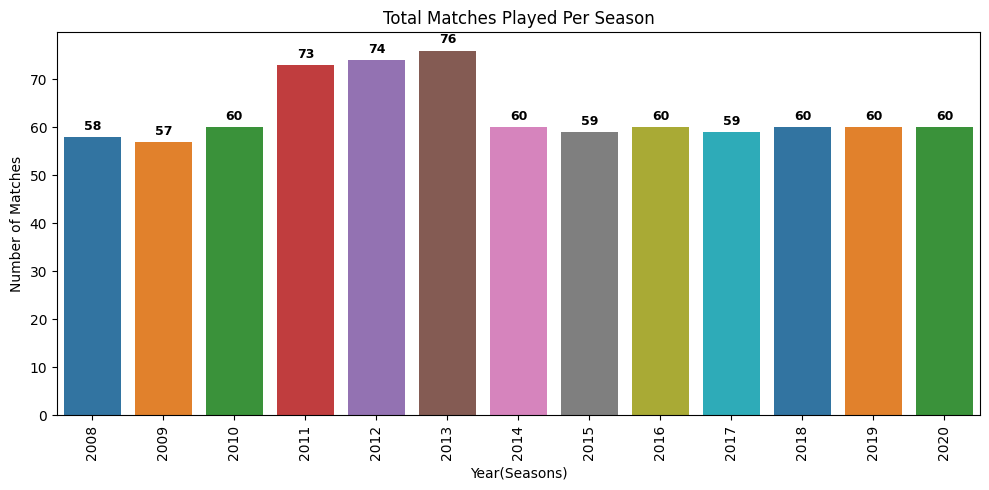

In [ ]:
# Create a bar chart for Total matches per season using plt
plt.figure(figsize=(10,5))
ax = sns.barplot(data=season_count, x='year', y='count', palette='tab10')

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=9, fontweight='bold')

plt.title('Total Matches Played Per Season')
plt.xlabel('Year(Seasons)')
plt.ylabel('Number of Matches')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Most Wins by Teams
winner_count = pd.read_sql_query ('''
select winner,count(*) as winner_count from IPL
where winner is not null
group by winner
order by winner_count desc
''',conn)

winner_count

,winner,winner_count
0,Mumbai Indians,120
1,Chennai Super Kings,106
2,Kolkata Knight Riders,99
3,Royal Challengers Bangalore,91
4,Kings XI Punjab,88
5,Rajasthan Royals,81
6,Delhi Daredevils,67
7,Sunrisers Hyderabad,66
8,Deccan Chargers,29
9,Delhi Capitals,19


In [ ]:
# A pie chart for team winning count
fig = px.pie(winner_count,
             values='winner_count',
             names='winner',
             title='Team Winning Count',
             color_discrete_sequence=px.colors.qualitative.Set1,
             width=800,
             height=600,
            )

fig.update_traces(textposition='inside', textinfo='percent', hole=0.4)

fig.show()

In [ ]:
# Losing count
loser_count = pd.read_sql_query ('''
SELECT
    CASE
        WHEN team1 = winner THEN team2
        WHEN team2 = winner THEN team1
    END AS loser,
    COUNT(*) as loser_count
FROM IPL
GROUP BY loser
ORDER BY loser_count DESC;
''',conn)

In [ ]:
# A pie chart for team losing
fig = px.pie(loser_count,
             values='loser_count',
             names='loser',
             title='Team Losing Count',
             color_discrete_sequence=px.colors.qualitative.D3,
             width=800,
             height=600,
            )

fig.update_traces(textposition='inside', textinfo='percent',hole = 0.4)

fig.show()

In [ ]:
# Merge winner and loser
winner_loser_count = pd.merge(winner_count,loser_count,left_on='winner',right_on='loser',how='left')

# print winner_loser_count
winner_loser_count

,winner,winner_count,loser,loser_count
0,Mumbai Indians,120,Mumbai Indians,83.0
1,Chennai Super Kings,106,Chennai Super Kings,72.0
2,Kolkata Knight Riders,99,Kolkata Knight Riders,93.0
3,Royal Challengers Bangalore,91,Royal Challengers Bangalore,101.0
4,Kings XI Punjab,88,Kings XI Punjab,102.0
5,Rajasthan Royals,81,Rajasthan Royals,78.0
6,Delhi Daredevils,67,Delhi Daredevils,92.0
7,Sunrisers Hyderabad,66,Sunrisers Hyderabad,58.0
8,Deccan Chargers,29,Deccan Chargers,46.0
9,Delhi Capitals,19,Delhi Capitals,14.0


In [ ]:
# Stacked Bar Chart of Wins and Losses
# How many times team won & loss the matches
# Create a stacked bar chart
fig = px.bar(winner_loser_count,
             x='winner',
             y=['winner_count', 'loser_count'],
             title='Wins and Losses per Team',
             labels={'winner': 'Team', 'value': 'Number of Matches', 'variable': 'Outcome'},
             color_discrete_sequence=px.colors.qualitative.D3
            )

# Customize the layout
fig.update_layout(barmode='stack') # Ensure bars are stacked

# Display the plot
fig.show()

In [ ]:
# Team who won tosses
toss_winner_count=pd.read_sql_query ('''
select toss_winner,count(*) as toss_wins from IPL
group by toss_winner
order by toss_wins desc
''',conn)

toss_winner_count

,toss_winner,toss_wins
0,Mumbai Indians,106
1,Kolkata Knight Riders,98
2,Chennai Super Kings,97
3,Royal Challengers Bangalore,87
4,Rajasthan Royals,87
5,Kings XI Punjab,85
6,Delhi Daredevils,80
7,Sunrisers Hyderabad,57
8,Deccan Chargers,43
9,Pune Warriors,20


In [ ]:
# A pie chart for team who won the toss
fig = px.pie(toss_winner_count,
             values='toss_wins',
             names='toss_winner',
             title='Team who won the toss',
             color_discrete_sequence=px.colors.qualitative.D3,
             width=800,
             height=600,
            )

fig.update_traces(textposition='inside', textinfo='percent', hole=0.4)

fig.show()


In [ ]:
#  Match win by toss decision
win_by_toss = pd.read_sql_query('''
SELECT
  toss_decision,
  COUNT(*) as total_taken,
  SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) as match_won,
  ROUND(SUM(CASE WHEN toss_winner = winner THEN 1.0 ELSE 0 END) * 100.0 / COUNT(*), 2) as win_percentage
FROM IPL
GROUP BY toss_decision
''', conn)

win_by_toss


,toss_decision,total_taken,match_won,win_percentage
0,bat,320,145,45.31
1,field,496,273,55.04


In [ ]:
# create a pie chart for wins by toss decision using donut chart

fig = px.pie(win_by_toss,
             values='win_percentage',
             names='toss_decision',
             title='Wins by Toss Decision',
             color_discrete_sequence=px.colors.qualitative.Vivid,
             width=700,
             height=500)
fig.update_traces(textposition='inside', textinfo='percent+value', hole=.4)

fig.show()

In [ ]:
# Average wins per season by team

avg_win_per_season = pd.read_sql_query('''
WITH team_season_wins AS (
    SELECT
        winner AS team,
        STRFTIME('%Y', date) AS season_year,
        COUNT(*) AS wins
    FROM IPL
    WHERE winner IS NOT NULL AND winner != 'Match Abandoned'
    GROUP BY winner, season_year
),
team_season_summary AS (
    SELECT
        team,
        SUM(wins) AS total_wins,
        COUNT(season_year) AS seasons_played,
        ROUND(SUM(wins) * 1.0 / COUNT(season_year), 2) AS avg_win_per_season
    FROM team_season_wins
    GROUP BY team
    HAVING seasons_played >= 2
)
SELECT *
FROM team_season_summary
ORDER BY total_wins DESC

''',conn)

avg_win_per_season

,team,total_wins,seasons_played,avg_win_per_season
0,Mumbai Indians,120,13,9.23
1,Chennai Super Kings,106,11,9.64
2,Kolkata Knight Riders,99,13,7.62
3,Royal Challengers Bangalore,91,13,7.00
4,Kings XI Punjab,88,13,6.77
5,Rajasthan Royals,81,11,7.36
6,Delhi Daredevils,67,11,6.09
7,Sunrisers Hyderabad,66,8,8.25
8,Deccan Chargers,29,5,5.80
9,Delhi Capitals,19,2,9.50


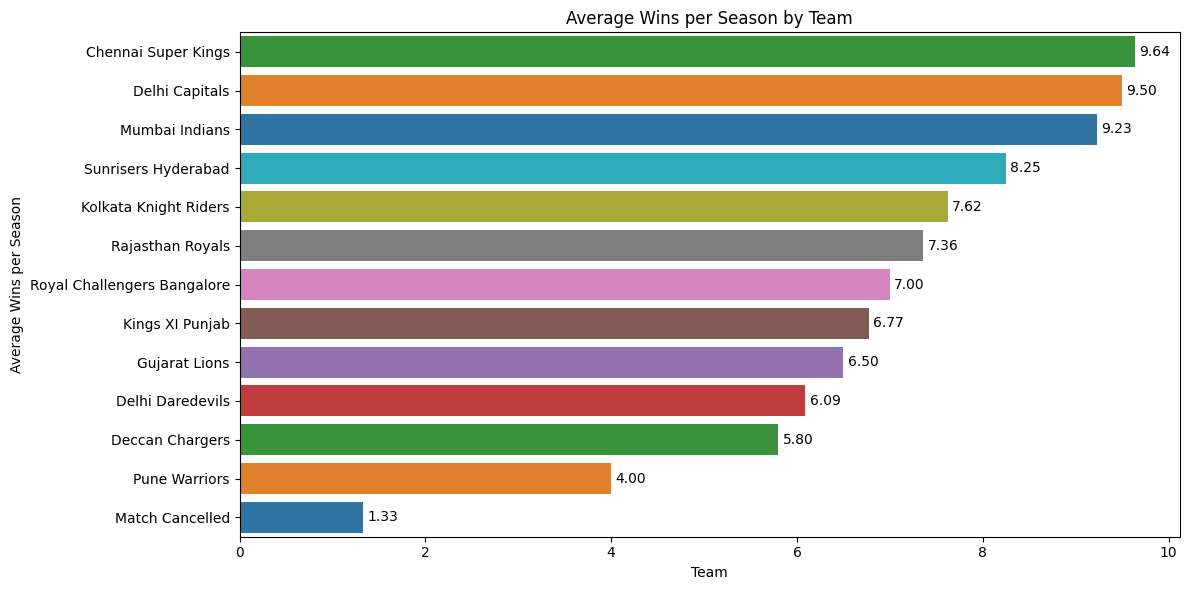

In [ ]:
# Create a average wins per season by team
data = avg_win_per_season.sort_values(by='avg_win_per_season', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot( data=data, x='avg_win_per_season', hue = 'avg_win_per_season', y='team', palette='tab10')

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=3)
ax.legend_.remove()
plt.title('Average Wins per Season by Team')
plt.xlabel('Team')
plt.ylabel('Average Wins per Season')
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 Player of the match awards
pom_count = pd.read_sql_query ('''
select player_of_match,count(*) as awards from IPL
group by player_of_match
order by awards desc
limit 10
''',conn)

pom_count

,player_of_match,awards
0,AB de Villiers,23
1,CH Gayle,22
2,RG Sharma,18
3,MS Dhoni,17
4,DA Warner,17
5,YK Pathan,16
6,SR Watson,16
7,SK Raina,14
8,V Kohli,13
9,G Gambhir,13


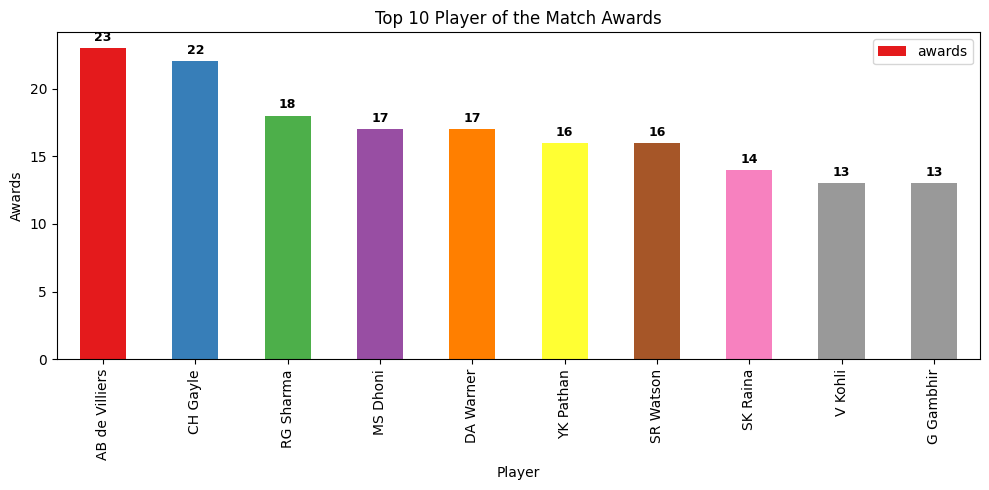

In [ ]:
# Bar chart for player of the match awards
colors = cm.Set1(range(len(pom_count)))
ax = pom_count.plot(kind = 'bar', x='player_of_match', y ='awards', color= colors, figsize =(10,5))

for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=9, fontweight='bold')
plt.title('Top 10 Player of the Match Awards')
plt.xlabel('Player')
plt.ylabel('Awards')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Analyze different match outcomes
match_outcomes = pd.read_sql_query ('''
select result,count(*) as count from IPL
group by result
order by count desc
''',conn)

match_outcomes

,result,count
0,wickets,435
1,runs,364
2,tie,13
3,Match Cancelled,4


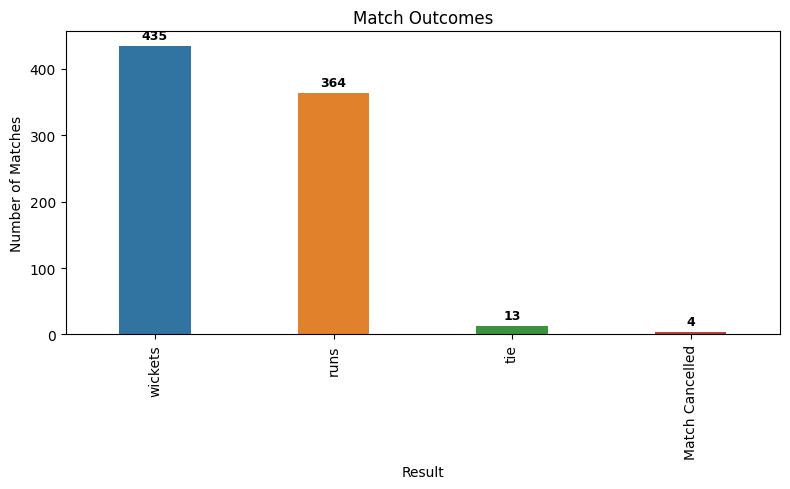

In [ ]:
# Create  a bar chart for match outcomes
plt.figure(figsize=(8,5))
ax = sns.barplot(data=match_outcomes, x='result', y='count', palette='tab10', width=0.4) # Added width parameter

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=9, fontweight='bold')

plt.title('Match Outcomes')
plt.xlabel('Result')
plt.ylabel('Number of Matches')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# calculates the total number of matches each umpire has officiated and their contribution
umpires =  pd.read_sql_query('''
WITH all_umpires as (
  select umpire1 as umpire from ipl where umpire1 is not null union all
  select umpire2 as umpire from ipl where umpire2 is not null ),

umpire_totals as (
    select umpire, count (*) as total_matches
    from all_umpires
    group by umpire),

overall_total as (
  select sum(total_matches) as total from umpire_totals)

select
  u.umpire,
  u.total_matches,
  round(u.total_matches*100.0 / t.total,1) as contribution_percent
from umpire_totals u, overall_total t
order by u.total_matches desc

''', conn)

umpires

,umpire,total_matches,contribution_percent
0,S Ravi,121,7.4
1,HDPK Dharmasena,94,5.8
2,AK Chaudhary,87,5.3
3,C Shamshuddin,82,5.0
4,M Erasmus,65,4.0
5,CK Nandan,57,3.5
6,Nitin Menon,57,3.5
7,SJA Taufel,55,3.4
8,Asad Rauf,51,3.1
9,VA Kulkarni,50,3.1


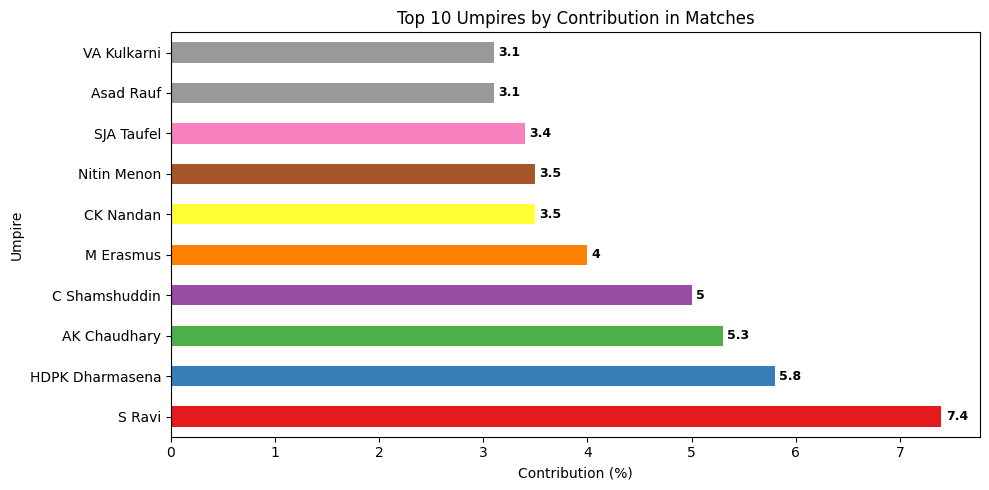

In [ ]:
# create a horizontal bar char chart for top 10 umpires by contribution in match
top_umpires = umpires.head(10)

colors = cm.Set1(range(len(top_umpires)))
ax = top_umpires.plot(kind = 'barh', x='umpire', y ='contribution_percent', color= colors, figsize =(10,5)) # Changed x='top_umpires' to x='umpire'

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=9, fontweight='bold')

plt.title('Top 10 Umpires by Contribution in Matches')
plt.xlabel('Contribution (%)')
plt.ylabel('Umpire')
plt.xticks(rotation=0)
ax.get_legend().remove()
plt.tight_layout()
plt.show()

In [ ]:
# Examining the distribution of elimninator matches
eliminator_matches = pd.read_sql_query ('''
select eliminator,count(*) as count from IPL
group by eliminator
order by count desc
''',conn)

eliminator_matches

,eliminator,count
0,N,799
1,Y,13
2,Match Cancelled,4


In [ ]:
# Create a pie plot to visualize eliminator matches
fig = px.pie(eliminator_matches,
             values='count',
             names='eliminator',
             title='Eliminator Matches',
             color_discrete_sequence=px.colors.qualitative.D3,
             width=700,
             height=600,
            )

fig.update_traces(textposition='inside', textinfo='percent', hole=0.4)

fig.show()

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***